# MIS: Clase Complementaria 4 (2025-20)
### Hoy tendremos dos cosas en mente:
(1) Implementar la medida de Beteenness de Freeman que quedó pendiente de la clase pasada.

(2) Ver las propiedades del modelo de formación de redes con grado deseado y entenderlo. Preguntarnos, ¿cómo mejorarlo?

Terminado esto, volveremos a centrarnos en medidas más complejas de importancia en las redes.

In [1]:
# Cargue de paquetes necesarios:
import numpy as np
import pandas as pd
import networkx as nx
import itertools
import scipy
from scipy.sparse import lil_matrix

#### Formula de Betweenness Freeman
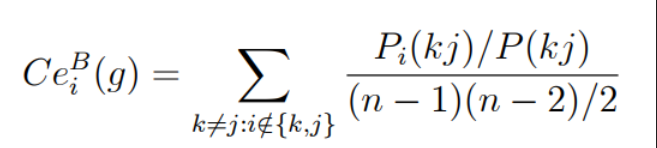

Donde P_i(kj) es el número de caminos más cortos entre k y j que pasan por i, mientras que P(kj) el número de caminos más cortos entre k y j.

In [2]:
# Aquí les dejo un grafo para que hagan sus pruebas
G = nx.erdos_renyi_graph(30,0.6)

In [ ]:
# Usando la estructura básica de aproximación de la clase pasada, construya esta medida. En el próximo bloque de código puede encontrar una implementación para comparar. 
# Porfa sea consciente y no lo mire.
def betweenness_freeman_mio(G:nx.Graph):
    '''
    Debe tomar un objeto tipo nx.Graph llamado "grafo" con n nodos, cuyos nodos son números del cero a n-1 (0,1,...,n-1) y retornar un diccionario con la medida solicitada.
    Input:
        G (nx.Graph): Grafo no dirigido de NetworkX.
    Output:
        diccionario (dict): Diccionario que contiene como llaves los nodos de grafo y como valores la medida de para cada llave.'''
    pass

In [ ]:
# Luego de construir su propio algoritmo, piense por qué este funciona. Discutamoslo en clase. Necesito que lean la documentación de all_shortest_pahts.
# Critique este algoritmo, revise por qué funciona o no:
def betweenness_freeman_complementario(G:nx.Graph):
    nodos = G.nodes # --
    n_nodos = len(nodos) # --
    correccion = n_nodos*(n_nodos-1)/2 # --
    sh = {tupla:nx.all_shortest_paths(G,tupla[0],tupla[1]) for tupla in itertools.combinations(nodos,2)} # --
    matriz = lil_matrix((len(nodos), len(sh)),dtype=int) # --
    vector = lil_matrix((1, len(sh)),dtype=float) # --
    contador = 0 # --
    for objeto in sh.values(): # --
        recorrer = list(objeto) # --
        vector[0,contador] = 1/len(recorrer) # --
        for c in recorrer: # --
            for fila in c[1:len(c)-1]: # --
                matriz[fila,contador]+=1 # --
        contador += 1 # --
    matriz = matriz.multiply(vector) # --
    del vector # --
    indice = matriz.sum(axis=1)/correccion # --
    indice = {i:indice[i,0] for i in range(len(indice))} # --
    return indice # --

¿Pueden dar una interpretación de la medida para cada uno de los nodos?

Si les interesa entender de un algoritmo que, parece, revolucionará la búsqueda de caminos más cortos sobre grafos, pueden leer este artículo:

https://arxiv.org/pdf/2504.17033


#### Modelo de grado esperado

Construiremos una función que implemente el modelo de Grado Esperado

In [ ]:
# Función que implementa el modelo de grado esperado. Use la función pop 
def grado_esperado_model(listado):
    '''
    Esta función recibe un listado de enteros (uno por cada nodo), que simboliza el grado esperado que tiene cada uno de ellos.
    Input:
        listado (list): Listado de enteros de longitud n. Cada entero debe estar entre cero y n-1.
    Output:
        nx.Graph : Grafo de NetworkX que se implementa a partir del modelo de grado esperado.
    '''
    pass

Actividad:

(1) Piense cómo mejorar este modelo para evitar self loops.

(2) Construya varios grafos tipo Erdos-Renyi de 10 nodos, con múltiples probabilidades de generación de enlaces. Comparelos, en términos de las métricas vistas en el curso, con un grafo del modelo de grafo esperado con un listado [5,5,...,5]. ¿Se parecen? ¿Cómo son distintos?